In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

ROOT = Path.home() / "Desktop" / "FinCascade"
DATA_DIR = ROOT / "data"
GRAPH_DIR = ROOT / "graph"

GRAPH_DIR.mkdir(exist_ok=True)

print("Project root:", ROOT)
print("Graph folder:", GRAPH_DIR)

Project root: C:\Users\Lenovo\Desktop\FinCascade
Graph folder: C:\Users\Lenovo\Desktop\FinCascade\graph


In [2]:
returns = pd.read_csv(
    DATA_DIR / "market_returns_model.csv",
    index_col=0,
    parse_dates=True
)

metadata = pd.read_csv(
    DATA_DIR / "entities.csv"
)

print("Returns shape:", returns.shape)
print("Entities:", len(metadata))
print("Date range:", returns.index.min(), "to", returns.index.max())

returns.head()

Returns shape: (1396, 26)
Entities: 26
Date range: 2021-01-05 00:00:00 to 2026-09-01 00:00:00


,AXISBANK.NS,BAJAJFINSV.NS,BAJFINANCE.NS,CL=F,DLF.NS,DRREDDY.NS,GC=F,GODREJPROP.NS,HCLTECH.NS,HDFCBANK.NS,...,MARUTI.NS,ONGC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TMPV.NS,WIPRO.NS,^NSEBANK,^NSEI
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-05,0.063631,-0.008754,-0.018634,0.048509,-0.010438,0.002779,0.004114,-0.000426,0.011169,0.007556,...,-0.006083,-0.020629,-0.012432,0.002491,-0.001572,0.017618,0.009932,0.024975,0.016333,0.004712
2021-01-06,-0.015351,-0.003911,-0.017328,0.014020,-0.002895,0.000265,-0.023455,0.038390,-0.013265,-0.004311,...,-0.003507,0.021064,-0.026372,0.011713,0.003066,-0.013417,0.011387,0.000246,0.002385,-0.003750
2021-01-07,0.025755,0.022950,0.010079,0.003950,0.018046,-0.003290,0.002832,-0.005340,-0.015999,-0.003027,...,-0.008199,0.009799,-0.001619,0.009297,-0.005617,-0.006128,0.006909,0.000861,0.004972,-0.000629
2021-01-08,0.002384,0.020427,0.000197,0.027740,0.011817,0.012778,-0.040893,0.007124,0.033349,0.010874,...,0.059324,0.028090,0.011799,-0.005909,0.031401,0.029049,0.007116,0.057652,0.004012,0.014847
2021-01-11,-0.008548,-0.020226,-0.019235,0.000191,-0.005437,0.014714,0.008451,0.006630,0.060775,0.013830,...,0.027181,0.018877,-0.018850,-0.012238,0.000322,0.017799,0.113550,0.038587,-0.002659,0.009584


In [3]:
corr_matrix = returns.corr()

print("Correlation matrix shape:", corr_matrix.shape)

corr_matrix.round(2)

Correlation matrix shape: (26, 26)


,AXISBANK.NS,BAJAJFINSV.NS,BAJFINANCE.NS,CL=F,DLF.NS,DRREDDY.NS,GC=F,GODREJPROP.NS,HCLTECH.NS,HDFCBANK.NS,...,MARUTI.NS,ONGC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TMPV.NS,WIPRO.NS,^NSEBANK,^NSEI
AXISBANK.NS,1.00,0.44,0.42,-0.02,0.45,0.14,0.06,0.35,0.16,0.46,...,0.33,0.21,0.35,0.55,0.14,0.18,0.34,0.21,0.75,0.62
BAJAJFINSV.NS,0.44,1.00,0.78,-0.04,0.48,0.12,0.10,0.41,0.25,0.41,...,0.34,0.16,0.37,0.43,0.22,0.26,0.35,0.29,0.57,0.64
BAJFINANCE.NS,0.42,0.78,1.00,-0.04,0.45,0.12,0.07,0.40,0.20,0.44,...,0.35,0.15,0.37,0.44,0.19,0.22,0.34,0.25,0.58,0.63
CL=F,-0.02,-0.04,-0.04,1.00,-0.00,0.02,0.07,0.00,0.04,-0.03,...,-0.08,0.14,0.02,-0.02,0.07,0.03,-0.01,0.03,-0.04,-0.01
DLF.NS,0.45,0.48,0.45,-0.00,1.00,0.17,0.08,0.70,0.28,0.41,...,0.38,0.28,0.43,0.55,0.29,0.25,0.51,0.34,0.61,0.66
DRREDDY.NS,0.14,0.12,0.12,0.02,0.17,1.00,0.02,0.18,0.20,0.15,...,0.14,0.12,0.18,0.16,0.36,0.19,0.19,0.23,0.17,0.31
GC=F,0.06,0.10,0.07,0.07,0.08,0.02,1.00,0.08,0.05,0.06,...,0.03,0.09,0.04,0.06,0.01,0.02,0.08,0.05,0.09,0.10
GODREJPROP.NS,0.35,0.41,0.40,0.00,0.70,0.18,0.08,1.00,0.23,0.34,...,0.31,0.24,0.39,0.44,0.25,0.23,0.42,0.30,0.50,0.58
HCLTECH.NS,0.16,0.25,0.20,0.04,0.28,0.20,0.05,0.23,1.00,0.23,...,0.18,0.16,0.27,0.17,0.21,0.67,0.25,0.59,0.26,0.49
HDFCBANK.NS,0.46,0.41,0.44,-0.03,0.41,0.15,0.06,0.34,0.23,1.00,...,0.31,0.13,0.37,0.43,0.18,0.22,0.32,0.28,0.79,0.71


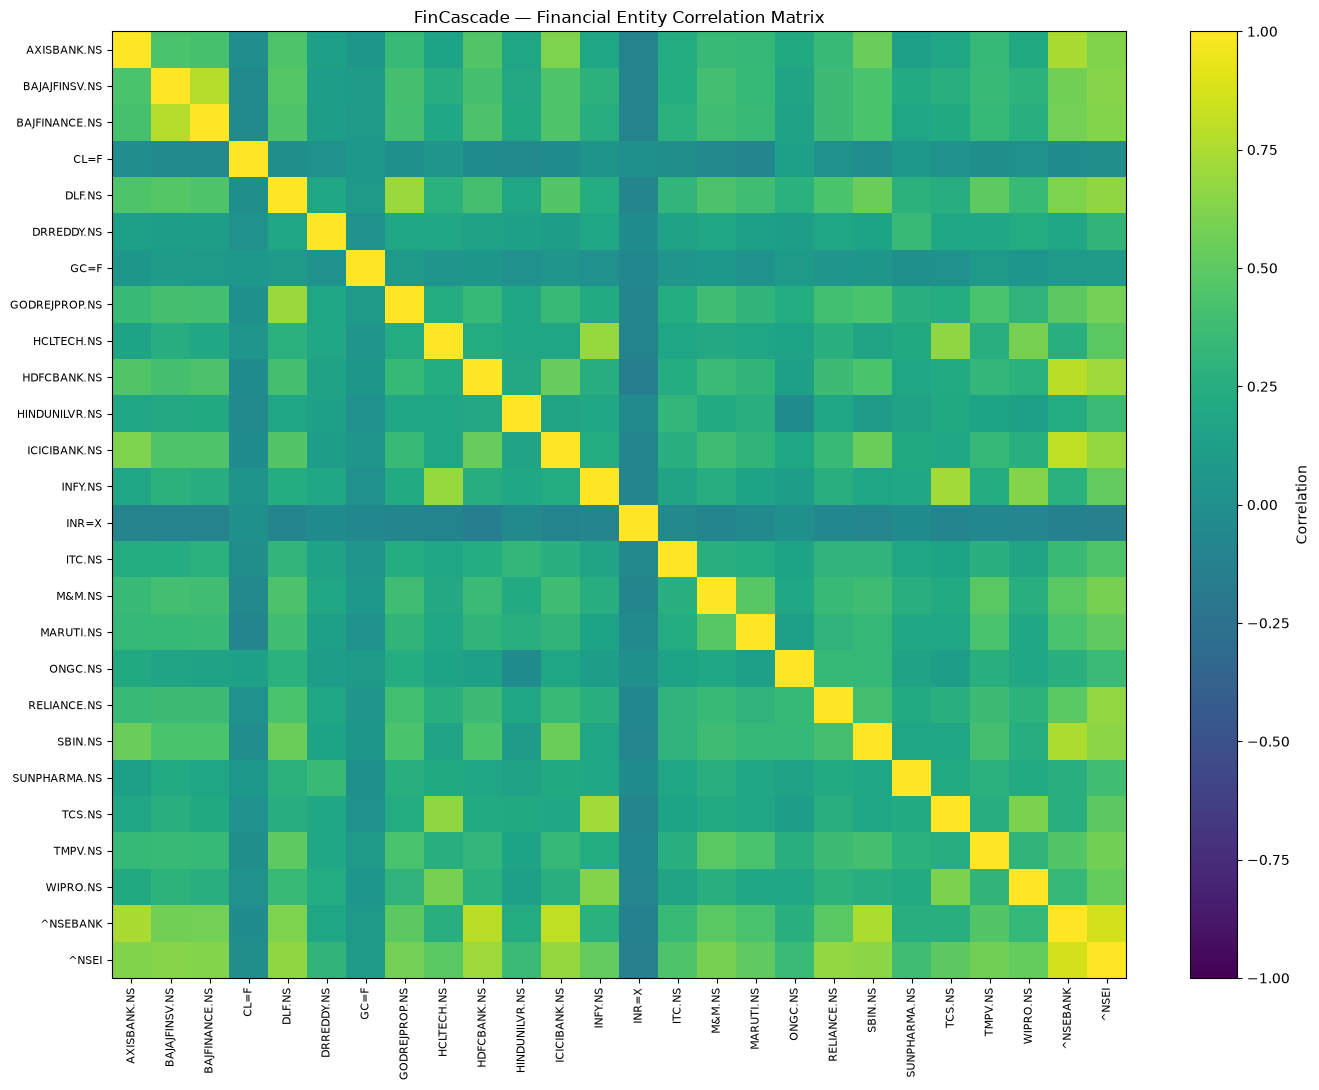

In [4]:
plt.figure(figsize=(14, 11))

plt.imshow(
    corr_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index,
    fontsize=8
)

plt.title("FinCascade — Financial Entity Correlation Matrix")

plt.tight_layout()
plt.show()

In [5]:
correlation_pairs = []

columns = corr_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        correlation_pairs.append({
            "source": columns[i],
            "target": columns[j],
            "correlation": corr_matrix.iloc[i, j]
        })

correlation_pairs = pd.DataFrame(correlation_pairs)

correlation_pairs["strength"] = (
    correlation_pairs["correlation"].abs()
)

correlation_pairs = correlation_pairs.sort_values(
    "strength",
    ascending=False
).reset_index(drop=True)

print("Total unique relationships:", len(correlation_pairs))

Total unique relationships: 325


In [6]:
ticker_names = metadata.set_index(
    "ticker"
)["name"].to_dict()

correlation_pairs["source_name"] = (
    correlation_pairs["source"].map(ticker_names)
)

correlation_pairs["target_name"] = (
    correlation_pairs["target"].map(ticker_names)
)

top_relationships = correlation_pairs[
    [
        "source",
        "source_name",
        "target",
        "target_name",
        "correlation",
        "strength"
    ]
].head(20)

top_relationships

,source,source_name,target,target_name,correlation,strength
0,^NSEBANK,Bank Nifty,^NSEI,NIFTY 50,0.871009,0.871009
1,ICICIBANK.NS,ICICI Bank,^NSEBANK,Bank Nifty,0.810765,0.810765
2,HDFCBANK.NS,HDFC Bank,^NSEBANK,Bank Nifty,0.789729,0.789729
3,BAJAJFINSV.NS,Bajaj Finserv,BAJFINANCE.NS,Bajaj Finance,0.779670,0.779670
4,SBIN.NS,SBI,^NSEBANK,Bank Nifty,0.752013,0.752013
5,AXISBANK.NS,Axis Bank,^NSEBANK,Bank Nifty,0.749901,0.749901
6,INFY.NS,Infosys,TCS.NS,TCS,0.720184,0.720184
7,HDFCBANK.NS,HDFC Bank,^NSEI,NIFTY 50,0.710270,0.710270
8,DLF.NS,DLF,GODREJPROP.NS,Godrej Properties,0.703059,0.703059
9,HCLTECH.NS,HCL Tech,INFY.NS,Infosys,0.692098,0.692098


In [7]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    count = (
        correlation_pairs["strength"] >= threshold
    ).sum()

    print(
        f"|correlation| >= {threshold:.1f}: "
        f"{count} relationships"
    )

|correlation| >= 0.2: 190 relationships
|correlation| >= 0.3: 118 relationships
|correlation| >= 0.4: 71 relationships
|correlation| >= 0.5: 36 relationships
|correlation| >= 0.6: 22 relationships
|correlation| >= 0.7: 9 relationships


In [8]:
CORR_THRESHOLD = 0.40

graph_edges = correlation_pairs[
    correlation_pairs["strength"] >= CORR_THRESHOLD
].copy()

print("Correlation threshold:", CORR_THRESHOLD)
print("Selected edges:", len(graph_edges))

Correlation threshold: 0.4
Selected edges: 71


In [9]:
G = nx.Graph()

# Add nodes
for _, row in metadata.iterrows():
    G.add_node(
        row["ticker"],
        name=row["name"],
        type=row["type"],
        sector=row["sector"]
    )

# Add edges
for _, row in graph_edges.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        correlation=float(row["correlation"]),
        weight=float(row["strength"]),
        relationship=(
            "positive"
            if row["correlation"] >= 0
            else "negative"
        )
    )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Connected components:", nx.number_connected_components(G))

isolated_nodes = list(nx.isolates(G))

print("\nIsolated nodes:", len(isolated_nodes))

for node in isolated_nodes:
    print(node, "-", G.nodes[node]["name"])

Nodes: 26
Edges: 71
Connected components: 8

Isolated nodes: 7
INR=X - USD/INR
CL=F - Crude Oil
GC=F - Gold
ONGC.NS - ONGC
SUNPHARMA.NS - Sun Pharma
DRREDDY.NS - Dr Reddy's
HINDUNILVR.NS - Hindustan Unilever


In [10]:
degree_centrality = nx.degree_centrality(G)

betweenness_centrality = nx.betweenness_centrality(
    G,
    weight=None
)

centrality_df = pd.DataFrame({
    "ticker": list(G.nodes()),
    "degree_centrality": [
        degree_centrality[node]
        for node in G.nodes()
    ],
    "betweenness_centrality": [
        betweenness_centrality[node]
        for node in G.nodes()
    ]
})

ticker_names = metadata.set_index("ticker")["name"].to_dict()
ticker_sectors = metadata.set_index("ticker")["sector"].to_dict()

centrality_df["name"] = centrality_df["ticker"].map(ticker_names)
centrality_df["sector"] = centrality_df["ticker"].map(ticker_sectors)

centrality_df = centrality_df[
    [
        "ticker",
        "name",
        "sector",
        "degree_centrality",
        "betweenness_centrality"
    ]
]

centrality_df.head()

,ticker,name,sector,degree_centrality,betweenness_centrality
0,^NSEI,NIFTY 50,Market,0.72,0.2595
1,^NSEBANK,Bank Nifty,Banking,0.52,0.0295
2,INR=X,USD/INR,Macro,0.00,0.0000
3,CL=F,Crude Oil,Energy,0.00,0.0000
4,GC=F,Gold,Safe Haven,0.00,0.0000


In [11]:
top_degree = centrality_df.sort_values(
    "degree_centrality",
    ascending=False
).head(10)

top_degree

,ticker,name,sector,degree_centrality,betweenness_centrality
0,^NSEI,NIFTY 50,Market,0.72,0.259500
1,^NSEBANK,Bank Nifty,Banking,0.52,0.029500
18,DLF.NS,DLF,Realty,0.48,0.017000
7,SBIN.NS,SBI,Banking,0.44,0.011222
25,BAJAJFINSV.NS,Bajaj Finserv,NBFC,0.40,0.006333
24,BAJFINANCE.NS,Bajaj Finance,NBFC,0.36,0.001667
6,ICICIBANK.NS,ICICI Bank,Banking,0.32,0.000000
5,HDFCBANK.NS,HDFC Bank,Banking,0.32,0.000000
8,AXISBANK.NS,Axis Bank,Banking,0.32,0.000000
15,TMPV.NS,Tata Motors Passenger Vehicles,Auto,0.28,0.004389


In [12]:
top_betweenness = centrality_df.sort_values(
    "betweenness_centrality",
    ascending=False
).head(10)

top_betweenness

,ticker,name,sector,degree_centrality,betweenness_centrality
0,^NSEI,NIFTY 50,Market,0.72,0.259500
1,^NSEBANK,Bank Nifty,Banking,0.52,0.029500
18,DLF.NS,DLF,Realty,0.48,0.017000
7,SBIN.NS,SBI,Banking,0.44,0.011222
25,BAJAJFINSV.NS,Bajaj Finserv,NBFC,0.40,0.006333
15,TMPV.NS,Tata Motors Passenger Vehicles,Auto,0.28,0.004389
16,M&M.NS,Mahindra & Mahindra,Auto,0.24,0.002500
24,BAJFINANCE.NS,Bajaj Finance,NBFC,0.36,0.001667
19,GODREJPROP.NS,Godrej Properties,Realty,0.28,0.001222
2,INR=X,USD/INR,Macro,0.00,0.000000


In [13]:
for node in G.nodes():

    G.nodes[node]["degree_centrality"] = float(
        degree_centrality[node]
    )

    G.nodes[node]["betweenness_centrality"] = float(
        betweenness_centrality[node]
    )

print("Centrality attributes added to graph.")

example_node = "^NSEI"

print("\nExample node:")
print(example_node)
print(G.nodes[example_node])

Centrality attributes added to graph.

Example node:
^NSEI
{'name': 'NIFTY 50', 'type': 'Index', 'sector': 'Market', 'degree_centrality': 0.72, 'betweenness_centrality': 0.2595}


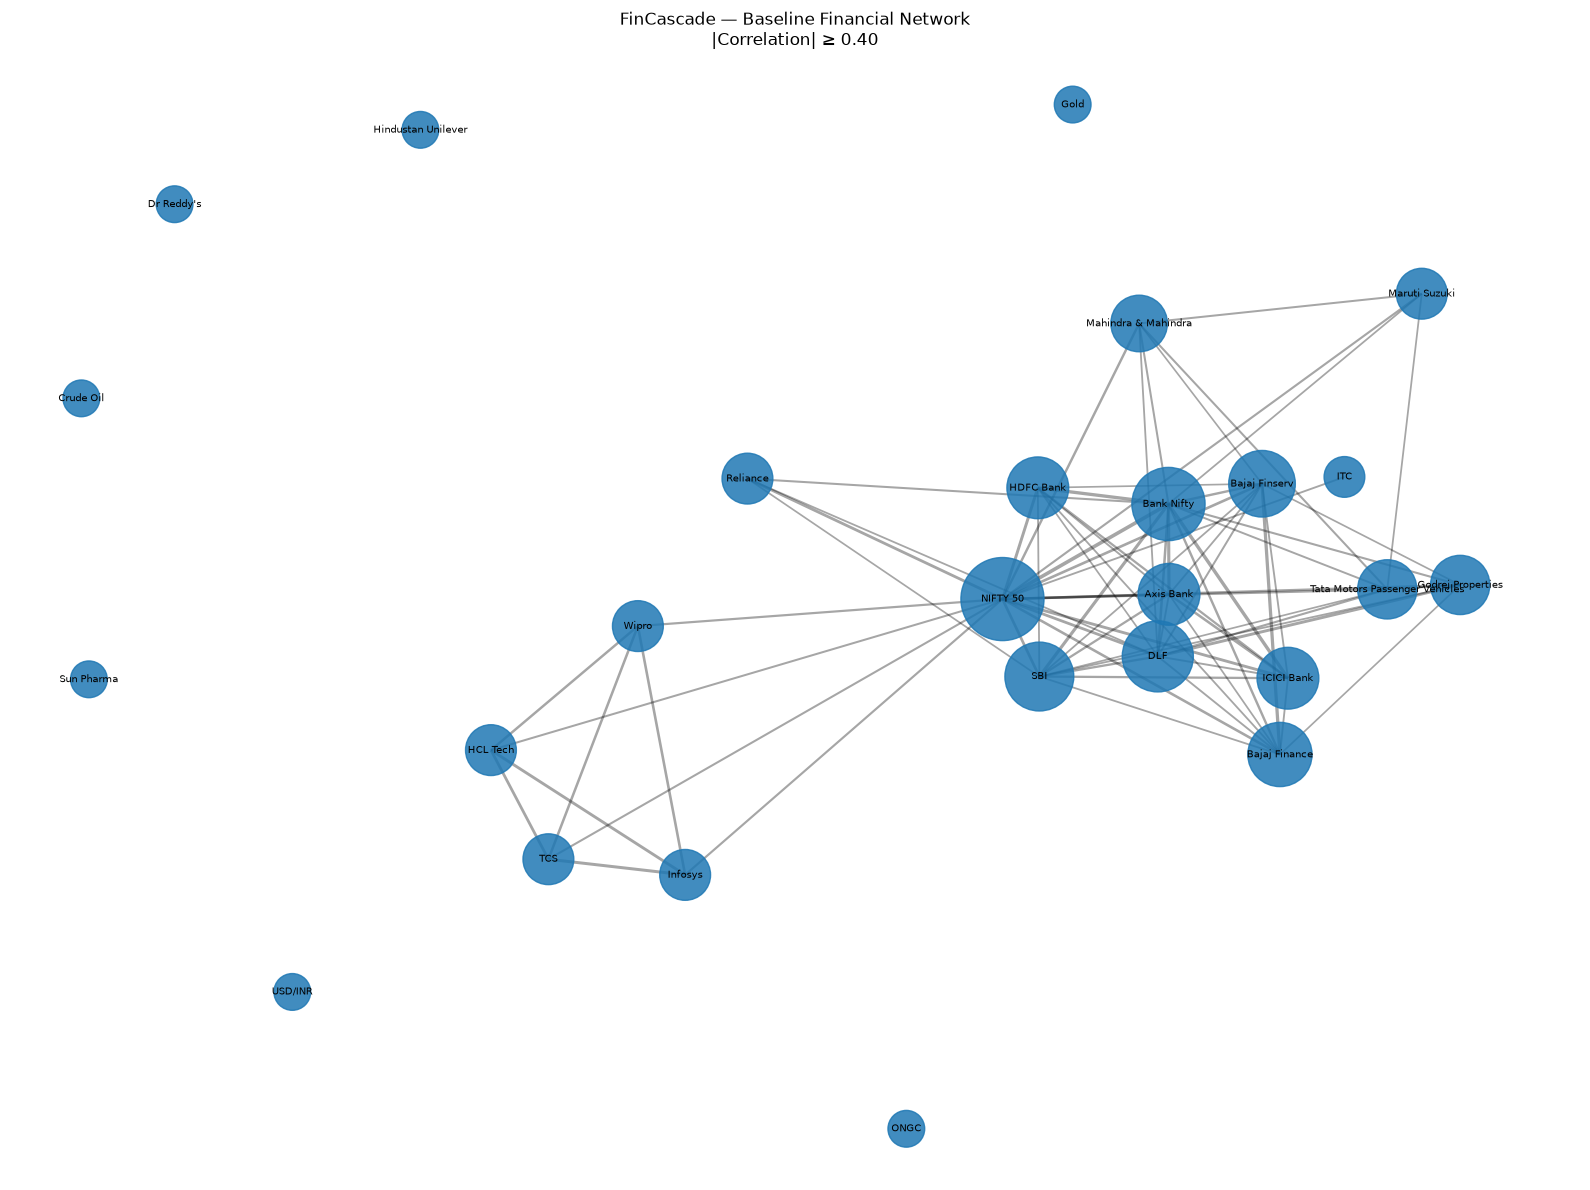

In [14]:
plt.figure(figsize=(16, 12))

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.8
)

node_sizes = [
    700 + degree_centrality[node] * 4000
    for node in G.nodes()
]

edge_widths = [
    G[u][v]["weight"] * 3
    for u, v in G.edges()
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    alpha=0.85
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.35
)

labels = {
    node: G.nodes[node]["name"]
    for node in G.nodes()
}

nx.draw_networkx_labels(
    G,
    pos,
    labels,
    font_size=7
)

plt.title(
    "FinCascade — Baseline Financial Network\n"
    "|Correlation| ≥ 0.40"
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [15]:
graph_edges.to_csv(
    DATA_DIR / "relationships_correlation.csv",
    index=False
)

centrality_df.to_csv(
    DATA_DIR / "centrality_metrics_correlation.csv",
    index=False
)

print("Saved:")
print("- relationships_correlation.csv")
print("- centrality_metrics_correlation.csv")

Saved:
- relationships_correlation.csv
- centrality_metrics_correlation.csv


In [16]:
def lagged_correlation(source, target, max_lag=5):

    results = []

    for lag in range(1, max_lag + 1):

        # Source return today
        x = returns[source]

        # Target return after 'lag' trading days
        y = returns[target].shift(-lag)

        temp = pd.concat([x, y], axis=1).dropna()

        corr = temp.iloc[:, 0].corr(
            temp.iloc[:, 1]
        )

        results.append({
            "lag": lag,
            "correlation": corr,
            "strength": abs(corr)
        })

    return pd.DataFrame(results)

print("Lagged correlation function ready.")

Lagged correlation function ready.


In [17]:
crude_ongc_lag = lagged_correlation(
    source="CL=F",
    target="ONGC.NS",
    max_lag=5
)

crude_ongc_lag

,lag,correlation,strength
0,1,0.247247,0.247247
1,2,-0.016228,0.016228
2,3,0.020429,0.020429
3,4,0.000332,0.000332
4,5,-0.021914,0.021914


In [18]:
lagged_relationships = []

tickers = list(returns.columns)

for source in tickers:

    for target in tickers:

        if source == target:
            continue

        lag_results = lagged_correlation(
            source,
            target,
            max_lag=5
        )

        best_row = lag_results.loc[
            lag_results["strength"].idxmax()
        ]

        lagged_relationships.append({
            "source": source,
            "target": target,
            "best_lag": int(best_row["lag"]),
            "lag_correlation": float(
                best_row["correlation"]
            ),
            "lag_strength": float(
                best_row["strength"]
            )
        })

lagged_df = pd.DataFrame(
    lagged_relationships
)

print(
    "Directional relationships tested:",
    len(lagged_df)
)

Directional relationships tested: 650


In [19]:
ticker_name_map = metadata.set_index(
    "ticker"
)["name"].to_dict()

ticker_sector_map = metadata.set_index(
    "ticker"
)["sector"].to_dict()

lagged_df["source_name"] = (
    lagged_df["source"].map(ticker_name_map)
)

lagged_df["target_name"] = (
    lagged_df["target"].map(ticker_name_map)
)

lagged_df["source_sector"] = (
    lagged_df["source"].map(ticker_sector_map)
)

lagged_df["target_sector"] = (
    lagged_df["target"].map(ticker_sector_map)
)

print("Metadata added.")

Metadata added.


In [20]:
top_lagged = lagged_df.sort_values(
    "lag_strength",
    ascending=False
)[
    [
        "source_name",
        "target_name",
        "best_lag",
        "lag_correlation",
        "lag_strength"
    ]
].head(20)

top_lagged

,source_name,target_name,best_lag,lag_correlation,lag_strength
91,Crude Oil,ONGC,1,0.247247,0.247247
638,NIFTY 50,USD/INR,1,-0.149673,0.149673
187,Godrej Properties,USD/INR,1,-0.132119,0.132119
84,Crude Oil,Hindustan Unilever,1,-0.129873,0.129873
613,Bank Nifty,USD/INR,1,-0.129610,0.129610
112,DLF,USD/INR,1,-0.128887,0.128887
162,Gold,USD/INR,1,-0.126230,0.126230
488,SBI,USD/INR,1,-0.123731,0.123731
619,Bank Nifty,SBI,4,0.115906,0.115906
166,Gold,ONGC,1,0.114103,0.114103


In [21]:
lag_thresholds = [0.05, 0.075, 0.10, 0.125, 0.15, 0.20]

for threshold in lag_thresholds:
    count = (
        lagged_df["lag_strength"] >= threshold
    ).sum()

    print(
        f"|lag correlation| >= {threshold:.3f}: "
        f"{count} relationships"
    )

|lag correlation| >= 0.050: 216 relationships
|lag correlation| >= 0.075: 53 relationships
|lag correlation| >= 0.100: 16 relationships
|lag correlation| >= 0.125: 7 relationships
|lag correlation| >= 0.150: 1 relationships
|lag correlation| >= 0.200: 1 relationships


In [22]:
LAG_THRESHOLD = 0.10

lagged_filtered = lagged_df[
    lagged_df["lag_strength"] >= LAG_THRESHOLD
].copy()

lagged_filtered = lagged_filtered.sort_values(
    "lag_strength",
    ascending=False
).reset_index(drop=True)

print("Lag threshold:", LAG_THRESHOLD)
print("Selected directional edges:", len(lagged_filtered))

lagged_filtered[
    [
        "source_name",
        "target_name",
        "best_lag",
        "lag_correlation",
        "lag_strength"
    ]
]

Lag threshold: 0.1
Selected directional edges: 16


,source_name,target_name,best_lag,lag_correlation,lag_strength
0,Crude Oil,ONGC,1,0.247247,0.247247
1,NIFTY 50,USD/INR,1,-0.149673,0.149673
2,Godrej Properties,USD/INR,1,-0.132119,0.132119
3,Crude Oil,Hindustan Unilever,1,-0.129873,0.129873
4,Bank Nifty,USD/INR,1,-0.129610,0.129610
5,DLF,USD/INR,1,-0.128887,0.128887
6,Gold,USD/INR,1,-0.126230,0.126230
7,SBI,USD/INR,1,-0.123731,0.123731
8,Bank Nifty,SBI,4,0.115906,0.115906
9,Gold,ONGC,1,0.114103,0.114103


In [23]:
isolated_tickers = list(nx.isolates(G))

isolated_connections = lagged_filtered[
    lagged_filtered["source"].isin(isolated_tickers)
    |
    lagged_filtered["target"].isin(isolated_tickers)
]

print(
    "Lagged relationships involving previously isolated nodes:",
    len(isolated_connections)
)

isolated_connections[
    [
        "source_name",
        "target_name",
        "best_lag",
        "lag_correlation",
        "lag_strength"
    ]
]

Lagged relationships involving previously isolated nodes: 13


,source_name,target_name,best_lag,lag_correlation,lag_strength
0,Crude Oil,ONGC,1,0.247247,0.247247
1,NIFTY 50,USD/INR,1,-0.149673,0.149673
2,Godrej Properties,USD/INR,1,-0.132119,0.132119
3,Crude Oil,Hindustan Unilever,1,-0.129873,0.129873
4,Bank Nifty,USD/INR,1,-0.129610,0.129610
5,DLF,USD/INR,1,-0.128887,0.128887
6,Gold,USD/INR,1,-0.126230,0.126230
7,SBI,USD/INR,1,-0.123731,0.123731
9,Gold,ONGC,1,0.114103,0.114103
10,Reliance,USD/INR,1,-0.111825,0.111825


In [24]:
DG = nx.DiGraph()

# Add all nodes
for _, row in metadata.iterrows():
    DG.add_node(
        row["ticker"],
        name=row["name"],
        type=row["type"],
        sector=row["sector"]
    )

# Add correlation edges in both directions
for _, row in graph_edges.iterrows():

    for source, target in [
        (row["source"], row["target"]),
        (row["target"], row["source"])
    ]:
        DG.add_edge(
            source,
            target,
            weight=float(row["strength"]),
            correlation=float(row["correlation"]),
            relationship_type="correlation",
            lag=0
        )

# Add lagged directional edges
for _, row in lagged_filtered.iterrows():

    source = row["source"]
    target = row["target"]

    if DG.has_edge(source, target):

        DG[source][target]["lag_strength"] = float(
            row["lag_strength"]
        )

        DG[source][target]["lag_correlation"] = float(
            row["lag_correlation"]
        )

        DG[source][target]["best_lag"] = int(
            row["best_lag"]
        )

        DG[source][target]["has_lag_signal"] = True

    else:

        DG.add_edge(
            source,
            target,
            weight=float(row["lag_strength"]),
            lag_strength=float(row["lag_strength"]),
            lag_correlation=float(row["lag_correlation"]),
            best_lag=int(row["best_lag"]),
            relationship_type="lagged",
            has_lag_signal=True
        )

print("Directed nodes:", DG.number_of_nodes())
print("Directed edges:", DG.number_of_edges())

print(
    "Weakly connected components:",
    nx.number_weakly_connected_components(DG)
)

isolated_directed = list(nx.isolates(DG))

print("\nRemaining isolated nodes:", len(isolated_directed))

for node in isolated_directed:
    print(node, "-", DG.nodes[node]["name"])

Directed nodes: 26
Directed edges: 155
Weakly connected components: 3

Remaining isolated nodes: 2
SUNPHARMA.NS - Sun Pharma
DRREDDY.NS - Dr Reddy's


In [25]:
lagged_df.to_csv(
    DATA_DIR / "relationships_lagged_all.csv",
    index=False
)

lagged_filtered.to_csv(
    DATA_DIR / "relationships_lagged_filtered.csv",
    index=False
)

print("Saved lagged relationship files.")

Saved lagged relationship files.


In [26]:
in_degree = nx.in_degree_centrality(DG)
out_degree = nx.out_degree_centrality(DG)

directed_betweenness = nx.betweenness_centrality(
    DG,
    weight=None
)

pagerank = nx.pagerank(
    DG,
    weight="weight"
)

directed_centrality = pd.DataFrame({
    "ticker": list(DG.nodes()),
    "in_degree": [
        in_degree[node]
        for node in DG.nodes()
    ],
    "out_degree": [
        out_degree[node]
        for node in DG.nodes()
    ],
    "betweenness": [
        directed_betweenness[node]
        for node in DG.nodes()
    ],
    "pagerank": [
        pagerank[node]
        for node in DG.nodes()
    ]
})

directed_centrality["name"] = (
    directed_centrality["ticker"].map(ticker_name_map)
)

directed_centrality["sector"] = (
    directed_centrality["ticker"].map(ticker_sector_map)
)

directed_centrality = directed_centrality[
    [
        "ticker",
        "name",
        "sector",
        "in_degree",
        "out_degree",
        "betweenness",
        "pagerank"
    ]
]

directed_centrality.sort_values(
    "out_degree",
    ascending=False
).head(10)

,ticker,name,sector,in_degree,out_degree,betweenness,pagerank
0,^NSEI,NIFTY 50,Market,0.72,0.76,0.269516,0.125837
1,^NSEBANK,Bank Nifty,Banking,0.52,0.56,0.031183,0.085538
18,DLF.NS,DLF,Realty,0.48,0.52,0.018127,0.066107
7,SBIN.NS,SBI,Banking,0.44,0.48,0.012016,0.060242
25,BAJAJFINSV.NS,Bajaj Finserv,NBFC,0.40,0.44,0.007460,0.054468
5,HDFCBANK.NS,HDFC Bank,Banking,0.32,0.36,0.000794,0.046203
24,BAJFINANCE.NS,Bajaj Finance,NBFC,0.36,0.36,0.001667,0.049871
15,TMPV.NS,Tata Motors Passenger Vehicles,Auto,0.28,0.32,0.005278,0.039950
6,ICICIBANK.NS,ICICI Bank,Banking,0.32,0.32,0.000000,0.049496
8,AXISBANK.NS,Axis Bank,Banking,0.32,0.32,0.000000,0.047067


In [27]:
top_bridges = directed_centrality.sort_values(
    "betweenness",
    ascending=False
).head(10)

top_bridges

,ticker,name,sector,in_degree,out_degree,betweenness,pagerank
0,^NSEI,NIFTY 50,Market,0.72,0.76,0.269516,0.125837
1,^NSEBANK,Bank Nifty,Banking,0.52,0.56,0.031183,0.085538
18,DLF.NS,DLF,Realty,0.48,0.52,0.018127,0.066107
7,SBIN.NS,SBI,Banking,0.44,0.48,0.012016,0.060242
25,BAJAJFINSV.NS,Bajaj Finserv,NBFC,0.40,0.44,0.007460,0.054468
15,TMPV.NS,Tata Motors Passenger Vehicles,Auto,0.28,0.32,0.005278,0.039950
16,M&M.NS,Mahindra & Mahindra,Auto,0.24,0.24,0.002500,0.036078
24,BAJFINANCE.NS,Bajaj Finance,NBFC,0.36,0.36,0.001667,0.049871
19,GODREJPROP.NS,Godrej Properties,Realty,0.28,0.32,0.001460,0.039714
5,HDFCBANK.NS,HDFC Bank,Banking,0.32,0.36,0.000794,0.046203


In [28]:
for node in DG.nodes():

    DG.nodes[node]["in_degree"] = float(
        in_degree[node]
    )

    DG.nodes[node]["out_degree"] = float(
        out_degree[node]
    )

    DG.nodes[node]["betweenness"] = float(
        directed_betweenness[node]
    )

    DG.nodes[node]["pagerank"] = float(
        pagerank[node]
    )

print("Directed centrality attributes added.")

Directed centrality attributes added.


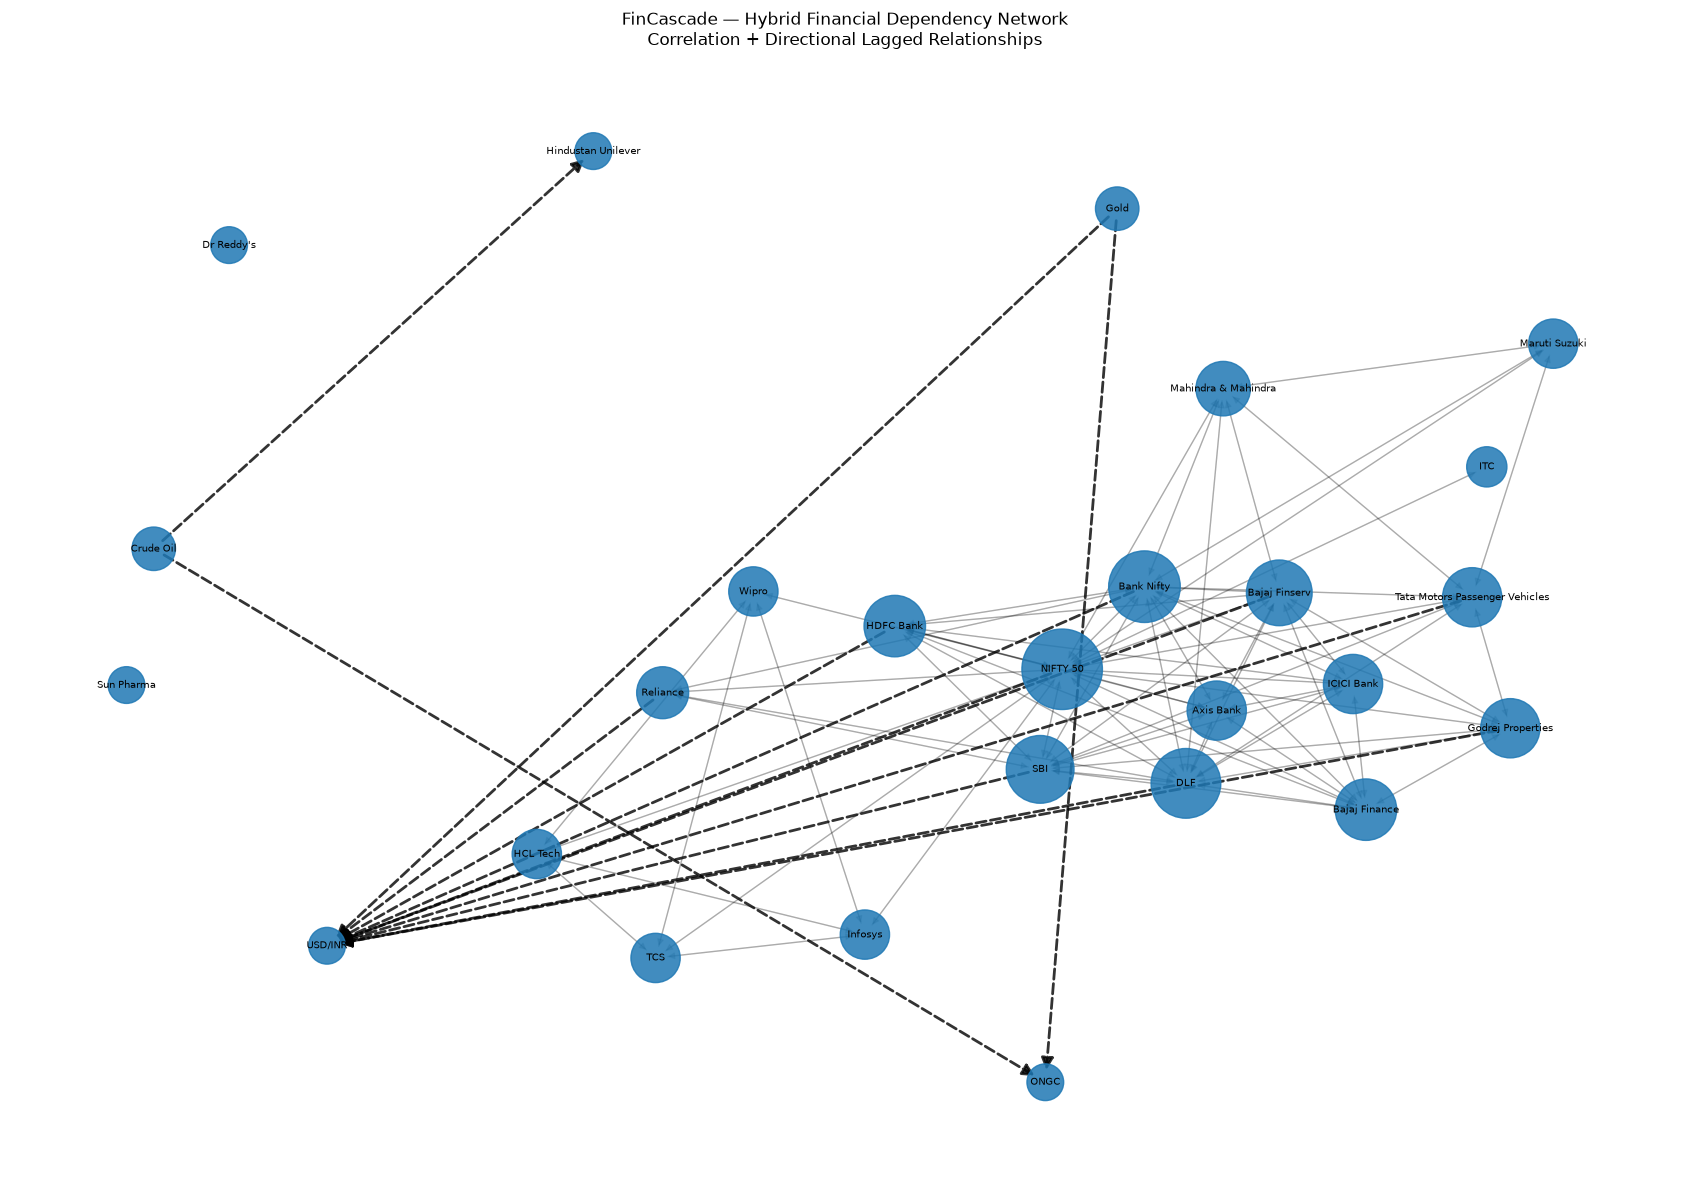

In [29]:
plt.figure(figsize=(17, 12))

pos = nx.spring_layout(
    DG,
    seed=42,
    k=0.9
)

node_sizes = [
    700 + out_degree[node] * 3500
    for node in DG.nodes()
]

corr_edges = [
    (u, v)
    for u, v, d in DG.edges(data=True)
    if d.get("relationship_type") == "correlation"
]

lag_edges = [
    (u, v)
    for u, v, d in DG.edges(data=True)
    if d.get("relationship_type") == "lagged"
]

nx.draw_networkx_nodes(
    DG,
    pos,
    node_size=node_sizes,
    alpha=0.85
)

nx.draw_networkx_edges(
    DG,
    pos,
    edgelist=corr_edges,
    alpha=0.18,
    arrows=True,
    arrowsize=10
)

nx.draw_networkx_edges(
    DG,
    pos,
    edgelist=lag_edges,
    alpha=0.8,
    width=2,
    style="dashed",
    arrows=True,
    arrowsize=18
)

labels = {
    node: DG.nodes[node]["name"]
    for node in DG.nodes()
}

nx.draw_networkx_labels(
    DG,
    pos,
    labels,
    font_size=7
)

plt.title(
    "FinCascade — Hybrid Financial Dependency Network\n"
    "Correlation + Directional Lagged Relationships"
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [30]:
import json

graph_json = {
    "nodes": [],
    "edges": []
}

for node, data in DG.nodes(data=True):

    graph_json["nodes"].append({
        "id": node,
        "name": data["name"],
        "type": data["type"],
        "sector": data["sector"],
        "in_degree": data.get("in_degree", 0),
        "out_degree": data.get("out_degree", 0),
        "betweenness": data.get("betweenness", 0),
        "pagerank": data.get("pagerank", 0)
    })

for source, target, data in DG.edges(data=True):

    graph_json["edges"].append({
        "source": source,
        "target": target,
        "weight": data.get("weight", 0),
        "relationship_type": data.get("relationship_type"),
        "correlation": data.get("correlation"),
        "lag_strength": data.get("lag_strength"),
        "lag_correlation": data.get("lag_correlation"),
        "best_lag": data.get("best_lag")
    })

graph_path = GRAPH_DIR / "graph.json"

with open(graph_path, "w", encoding="utf-8") as f:
    json.dump(
        graph_json,
        f,
        indent=4
    )

print("Graph exported successfully.")
print("Path :", graph_path)
print("Nodes:", len(graph_json["nodes"]))
print("Edges:", len(graph_json["edges"]))

Graph exported successfully.
Path : C:\Users\Lenovo\Desktop\FinCascade\graph\graph.json
Nodes: 26
Edges: 155


In [31]:
directed_centrality.to_csv(
    DATA_DIR / "centrality_metrics_directed.csv",
    index=False
)

print("Saved: centrality_metrics_directed.csv")

Saved: centrality_metrics_directed.csv


In [32]:
print("===== NOTEBOOK 03 SUMMARY =====")

print("\nFinancial entities:")
print(DG.number_of_nodes())

print("\nCorrelation edges:")
print(len(graph_edges))

print("\nFiltered lagged edges:")
print(len(lagged_filtered))

print("\nDirected graph edges:")
print(DG.number_of_edges())

print("\nWeakly connected components:")
print(nx.number_weakly_connected_components(DG))

print("\nRemaining isolated nodes:")
print(list(nx.isolates(DG)))

print("\nGraph JSON exists:")
print((GRAPH_DIR / "graph.json").exists())

===== NOTEBOOK 03 SUMMARY =====

Financial entities:
26

Correlation edges:
71

Filtered lagged edges:
16

Directed graph edges:
155

Weakly connected components:
3

Remaining isolated nodes:
['SUNPHARMA.NS', 'DRREDDY.NS']

Graph JSON exists:
True
